# Parameter quality evaluation

In this notebook we evaluate parameter quality on the quantum hardware.

In [1]:
import json
import glob
import matplotlib.pyplot as plt

from qaoa_parameter_setting.utils.hardware_execution import HarwareExecutor

The cell below can be used to get a sense of how much data there is for the different graphs. It is optional to run, it helps pick an instance to analyze.

In [48]:
with open("data/training/best_parameters_summary.json", "r") as fin:
    summary = json.load(fin)

summary["MPS"].keys()

dict_keys(['000_100nodes_random3regular.json', '000_40nodes_random3regular.json', '001_40nodes_random3regular.json', '002_40nodes_random3regular.json', '003_40nodes_random3regular.json', '004_40nodes_random3regular.json', '000_40nodes_random4regular.json', '004_40nodes_random4regular.json', '003_40nodes_random4regular.json', '002_40nodes_random4regular.json', '001_40nodes_random4regular.json', '000_5_3_heavyhex_106nodes_weighted.json', '000_4_1_heavyhex_39nodes_weighted.json', '001_4_1_heavyhex_39nodes_weighted.json', '002_4_1_heavyhex_39nodes_weighted.json', '003_4_1_heavyhex_39nodes_weighted.json', '004_4_1_heavyhex_39nodes_weighted.json', '000_40nodes_8swap_layers.json', '000_40nodes_erdosrenyi20percent.json'])

In [2]:
instance = "000_5_3_heavyhex_106nodes_weighted.json"
short_name = "000N106HH53"
folder = "heavy_hex"

executor = HarwareExecutor(instance, short_name, folder)

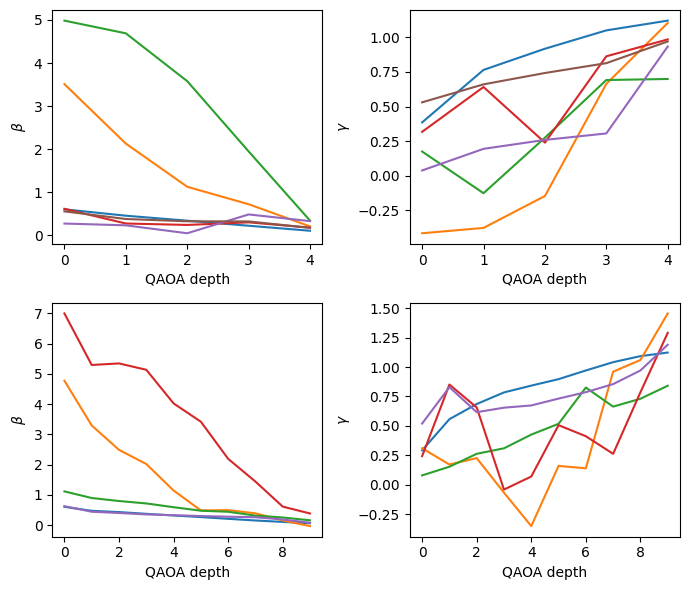

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(7, 6))
executor.plot_qaoa_angles(5, fig, axs[0][0], axs[0][1])
executor.plot_qaoa_angles(10, fig, axs[1][0], axs[1][1])
fig.tight_layout()

## Build the QAOA circuit

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

In [5]:
service = QiskitRuntimeService(instance="optimization-premium-us")
backend = service.backend("ibm_kingston")

management.get:WARNING:2025-10-10 14:30:31,084: Loading default saved account


In [7]:
pub = executor.make_sampler_pub(backend, qaoa_depth=5, problem_class="maxcut")

C:\Users\DanielEgger\OneDrive - IBM\Documents\qiskit\QAOA-Parameter-Setting\qaoa_parameter_setting\transpilation\make_qaoa_circuits.py:331: UserWarning: No good rings found to execute instances/heavy_hex/000_5_3_heavyhex_106nodes_weighted.json on based on gate fidelity.
  warn(f"No good rings found to execute {file_name} on based on gate fidelity.")


In [9]:
print("Instruction count:", pub[0].count_ops())
print("2Q gate depth:", pub[0].depth(lambda x: len(x.qubits) > 1))

Instruction count: OrderedDict({'rz': 2472, 'sx': 1766, 'cz': 1200, 'measure': 106})
2Q gate depth: 30


In [10]:
pub[0].draw("mpl", fold=False, idle_wires=False)

### Execute on the hardware

In [11]:
sampler = SamplerV2(mode=backend)

In [12]:
job = sampler.run(pub, shots=2**12)

In [14]:
print(job.status())
print(job.job_id())

'DONE'

Get the result and save it. This is to be run when the job is done.

In [6]:
job_ = service.job("d3kfmngdd19c738g6t60")

In [9]:
res_summary = executor.save_result_summary(job_)

### Load results from past executions and plot them

In [10]:
with open(f"data/hardware/{folder}/{short_name}_d3kfmngdd19c738g6t60.json", "r") as fin:
    res_summary = json.load(fin)

In [17]:
import numpy as np

from qaoa_training_pipeline.visualization.plotting import plot_cdf
from qaoa_training_pipeline.utils.graph_utils import load_graph, solve_max_cut, graph_to_operator

from qopt_best_practices.cost_function.cost_utils import counts_to_maxcut_cost

from qaoa_parameter_setting.utils.analysis import mean_obj, standard_error_mean

To compute performance we need to get the graph and the extremal values of the objective to compute the approximation ratio.

In [12]:
graph = load_graph(f"instances/{folder}/{instance}")
cost_op = graph_to_operator(graph)

In [13]:
max_cut, min_cut, _ = solve_max_cut(cost_op)

We compare the cumulative distributions of the samples from the methods as well as the mean of these distributions.

In [14]:
mc_costs = [counts_to_maxcut_cost(graph, res["counts"]) for res in res_summary]

In [21]:
means = [100*(mean_obj(mc_cost) - min_cut)/(max_cut - min_cut) for mc_cost in mc_costs]
sems = np.array([100*(standard_error_mean(mc_cost, sum(res_summary[idx]["counts"].values())))/(max_cut - min_cut) for idx, mc_cost in enumerate(mc_costs)])

Text(0.5, 0, 'Best approximated energy')

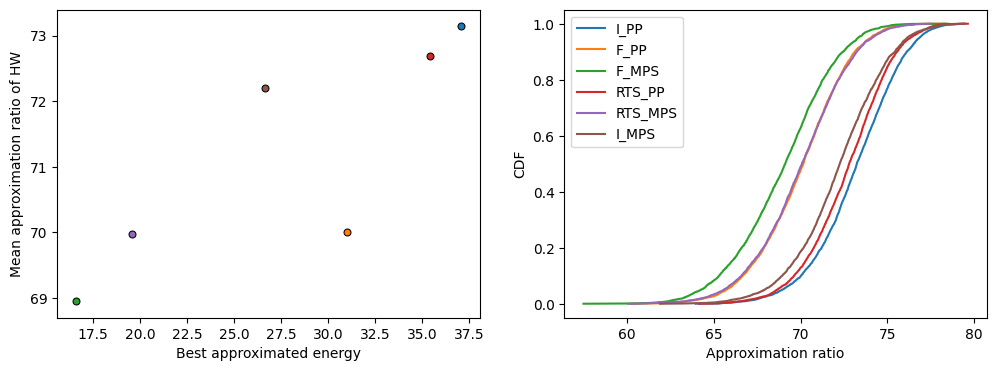

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for idx, mc_cost in enumerate(mc_costs):
    plot_cdf(
        {(k-min_cut)/(max_cut-min_cut)*100: v for k, v in mc_cost.items()}, 
        axis=axs[1], 
        label=res_summary[idx]["metadata"]["circuit_metadata"]["method"]
    )

    _approx_e = [res_summary[idx]["metadata"]["circuit_metadata"]["eval_energy"]]
    axs[0].errorbar(_approx_e, [means[idx]], yerr=[sems[idx]], ms=5, marker="o", mec="k", mew=0.75)

axs[1].legend()
axs[1].set_xlabel("Approximation ratio")
axs[1].set_ylabel("CDF")
axs[0].set_ylabel("Mean approximation ratio of HW")
axs[0].set_xlabel("Best approximated energy")
#fig.savefig(f"{short_name}_hm_results.pdf", bbox_inches="tight")